This notebook contains the EDA and Data Preprocessing for medical insurance charges data.

In [2]:
#This is Global plot style
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

In [3]:
import urllib.request
import os
os.makedirs("datasets", exist_ok=True)
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
urllib.request.urlretrieve(url, "datasets/insurance.csv")
print("Downloaded!")

Downloaded!


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("datasets/insurance.csv")

# Here I am adding some missing values and duplicates to simulate a real-world scenario
np.random.seed(15)
df.loc[df.sample(frac=0.08).index, 'age'] = np.nan
df.loc[df.sample(frac=0.08).index, 'bmi'] = np.nan
df = pd.concat([df, df.sample(15)], ignore_index=True)

print(df.shape)
print(df.head())
print(df.dtypes)


(1353, 7)
    age     sex     bmi  children smoker     region      charges
0  19.0  female  27.900         0    yes  southwest  16884.92400
1  18.0    male     NaN         1     no  southeast   1725.55230
2  28.0    male  33.000         3     no  southeast   4449.46200
3  33.0    male  22.705         0     no  northwest  21984.47061
4  32.0    male  28.880         0     no  northwest   3866.85520
age         float64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


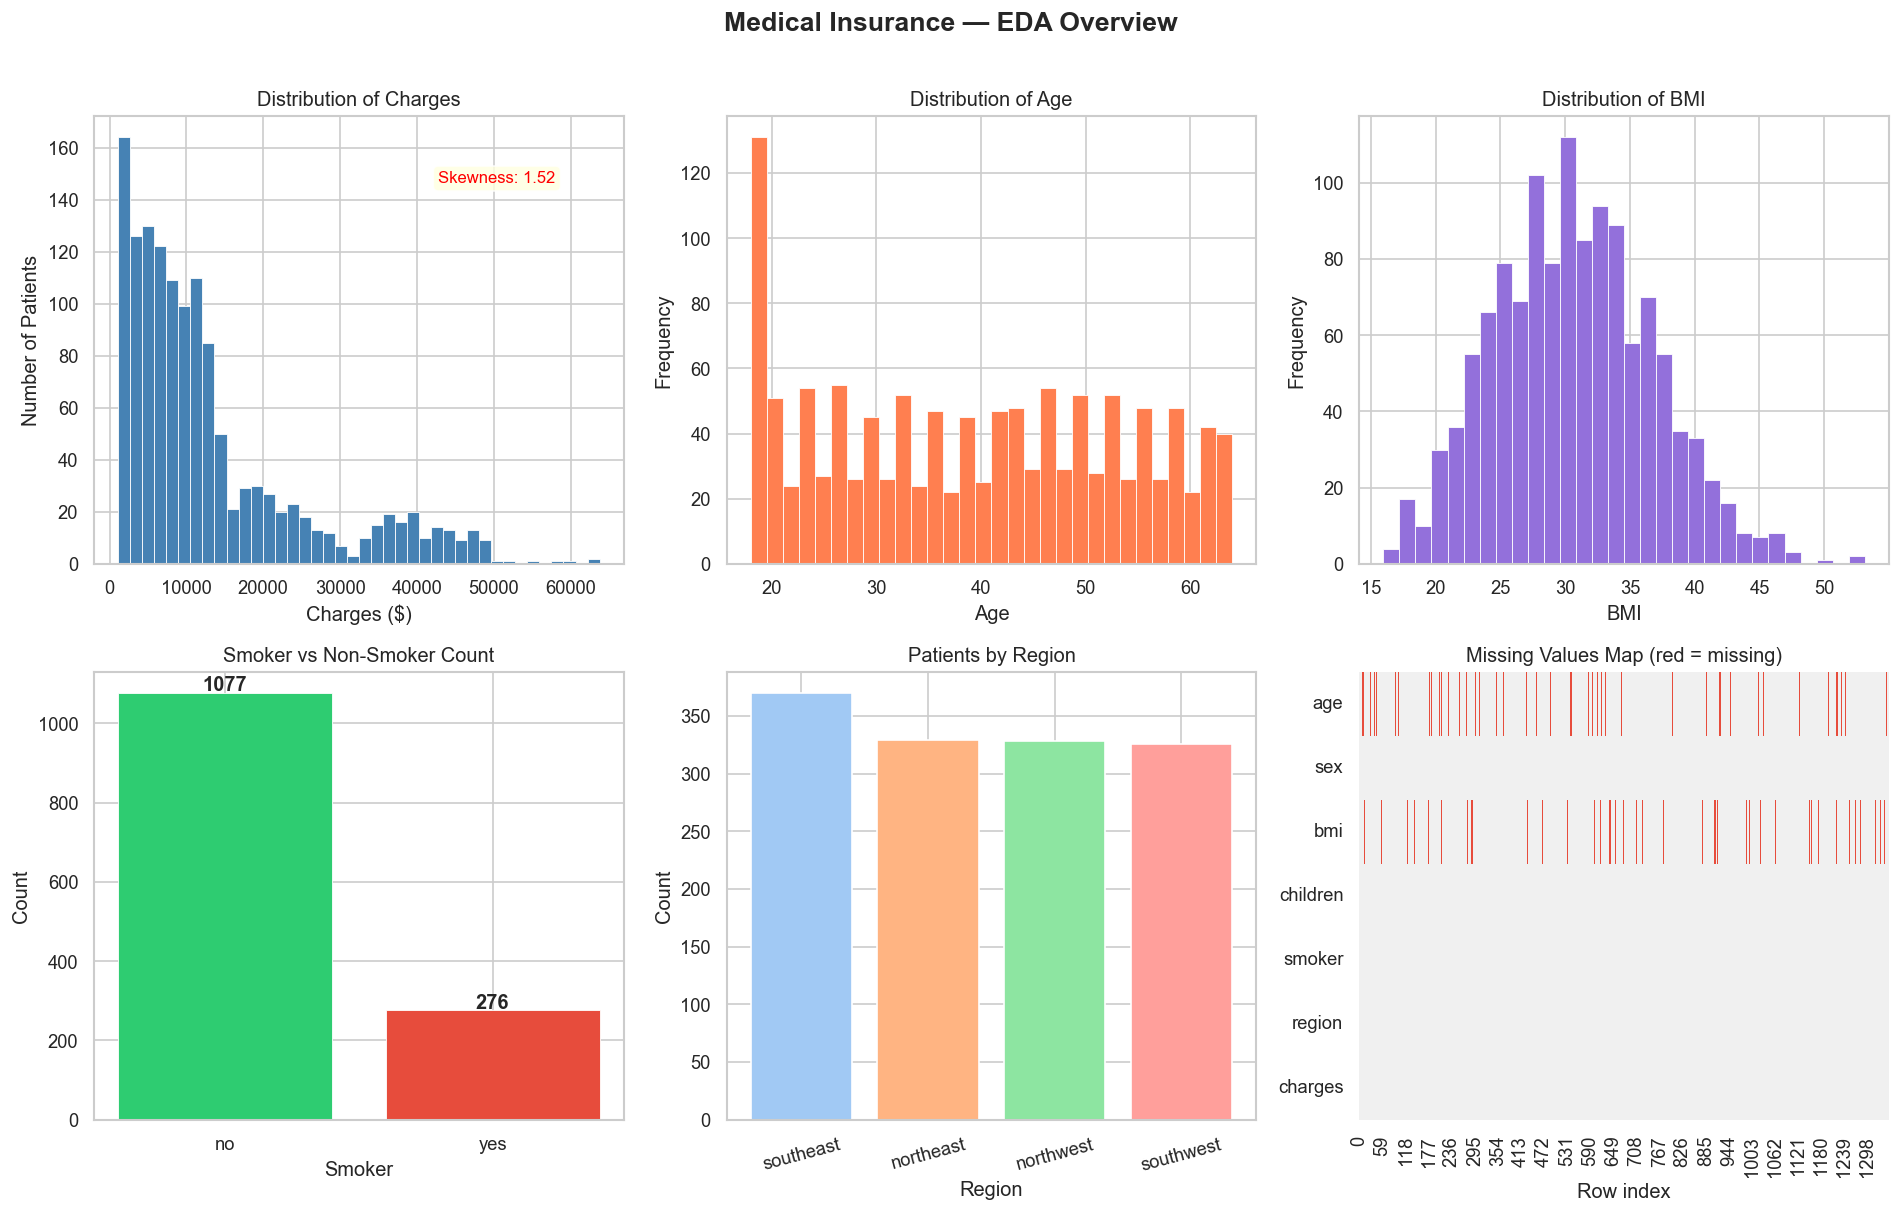

In [11]:
# Global plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Medical Insurance — EDA Overview", fontsize=16, fontweight='bold', y=1.01)

# 1A — Distribution of Charges
axes[0, 0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0, 0].set_title("Distribution of Charges")
axes[0, 0].set_xlabel("Charges ($)")
axes[0, 0].set_ylabel("Number of Patients")
skew_val = df['charges'].skew()
axes[0, 0].text(0.65, 0.85, f"Skewness: {skew_val:.2f}",
                transform=axes[0, 0].transAxes,
                fontsize=10, color='red',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# 1B — Distribution of Age
axes[0, 1].hist(df['age'].dropna(), bins=30, color='coral', edgecolor='white', linewidth=0.5)
axes[0, 1].set_title("Distribution of Age")
axes[0, 1].set_xlabel("Age")
axes[0, 1].set_ylabel("Frequency")

# 1C — Distribution of BMI
axes[0, 2].hist(df['bmi'].dropna(), bins=30, color='mediumpurple', edgecolor='white', linewidth=0.5)
axes[0, 2].set_title("Distribution of BMI")
axes[0, 2].set_xlabel("BMI")
axes[0, 2].set_ylabel("Frequency")

# 1D — Smoker count
smoker_counts = df['smoker'].value_counts()
axes[1, 0].bar(smoker_counts.index, smoker_counts.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=0.5)
axes[1, 0].set_title("Smoker vs Non-Smoker Count")
axes[1, 0].set_xlabel("Smoker")
axes[1, 0].set_ylabel("Count")
for i, v in enumerate(smoker_counts.values):
    axes[1, 0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 1E — Region distribution
region_counts = df['region'].value_counts()
axes[1, 1].bar(region_counts.index, region_counts.values,
               color=sns.color_palette("pastel", 4), edgecolor='white')
axes[1, 1].set_title("Patients by Region")
axes[1, 1].set_xlabel("Region")
axes[1, 1].set_ylabel("Count")
axes[1, 1].tick_params(axis='x', rotation=15)

# 1F — Missing value heatmap
missing_data = df.isnull().astype(int)
sns.heatmap(missing_data.T, ax=axes[1, 2], cbar=False,
            cmap=['#f0f0f0', '#e74c3c'], yticklabels=True)
axes[1, 2].set_title("Missing Values Map (red = missing)")
axes[1, 2].set_xlabel("Row index")

plt.tight_layout()
plt.show()


EDA relationship with charges

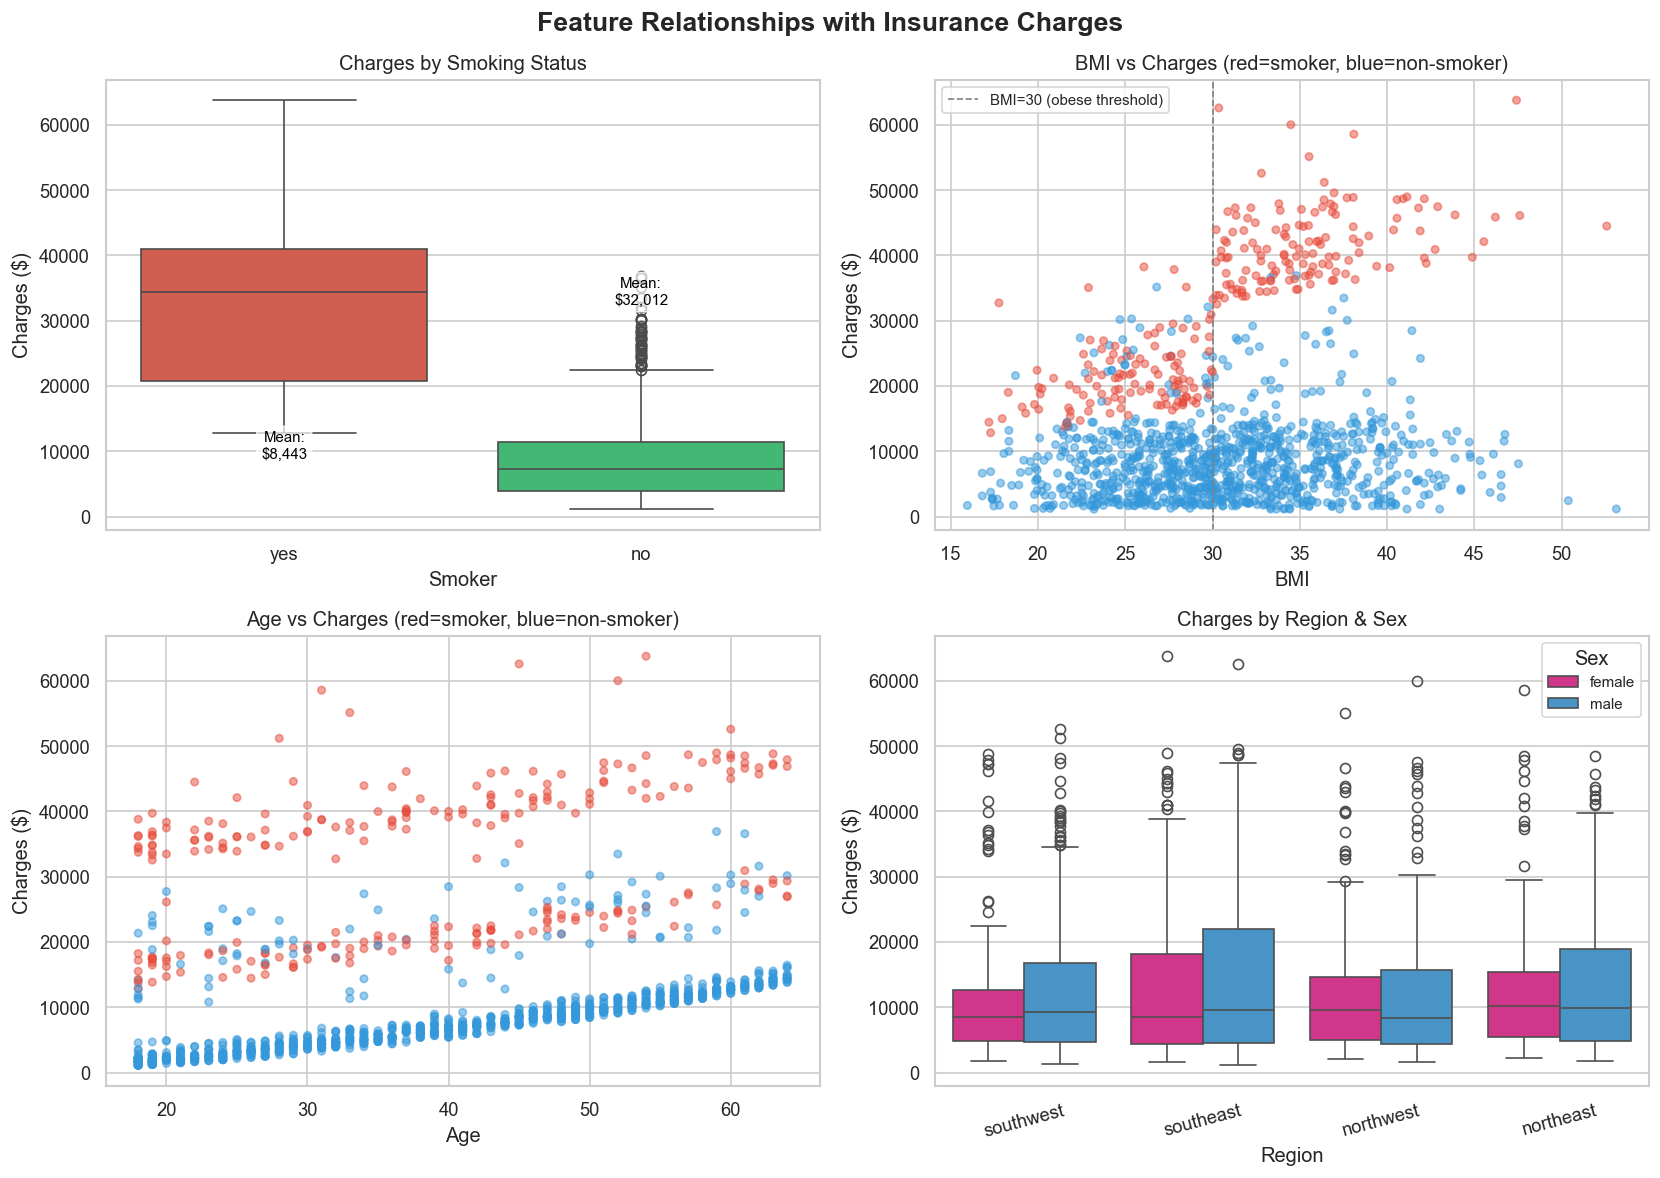

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature Relationships with Insurance Charges", fontsize=16, fontweight='bold')

# 2A — Charges by Smoker (most impactful feature)
sns.boxplot(data=df, x='smoker', y='charges', palette={'yes': '#e74c3c', 'no': '#2ecc71'},
            ax=axes[0, 0])
axes[0, 0].set_title("Charges by Smoking Status")
axes[0, 0].set_xlabel("Smoker")
axes[0, 0].set_ylabel("Charges ($)")

# Annotate means
for i, val in enumerate(['no', 'yes']):
    mean_val = df[df['smoker'] == val]['charges'].mean()
    axes[0, 0].text(i, mean_val + 500, f"Mean:\n${mean_val:,.0f}",
                    ha='center', fontsize=9, color='black',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# 2B — BMI vs Charges (scatter with smoker hue — KEY INSIGHT)
colors = df['smoker'].map({'yes': '#e74c3c', 'no': '#3498db'})
axes[0, 1].scatter(df['bmi'], df['charges'], c=colors, alpha=0.5, s=20)
axes[0, 1].set_title("BMI vs Charges (red=smoker, blue=non-smoker)")
axes[0, 1].set_xlabel("BMI")
axes[0, 1].set_ylabel("Charges ($)")
axes[0, 1].axvline(x=30, color='gray', linestyle='--', linewidth=1, label='BMI=30 (obese threshold)')
axes[0, 1].legend(fontsize=9)

# 2C — Age vs Charges
axes[1, 0].scatter(df['age'], df['charges'],
                   c=df['smoker'].map({'yes': '#e74c3c', 'no': '#3498db'}),
                   alpha=0.5, s=20)
axes[1, 0].set_title("Age vs Charges (red=smoker, blue=non-smoker)")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Charges ($)")

# 2D — Charges by Region & Sex
sns.boxplot(data=df, x='region', y='charges', hue='sex',
            palette={'male': '#3498db', 'female': '#e91e8c'}, ax=axes[1, 1])
axes[1, 1].set_title("Charges by Region & Sex")
axes[1, 1].set_xlabel("Region")
axes[1, 1].set_ylabel("Charges ($)")
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].legend(title='Sex', fontsize=9)

plt.tight_layout()
plt.show()

EDA correlation and Log Transform

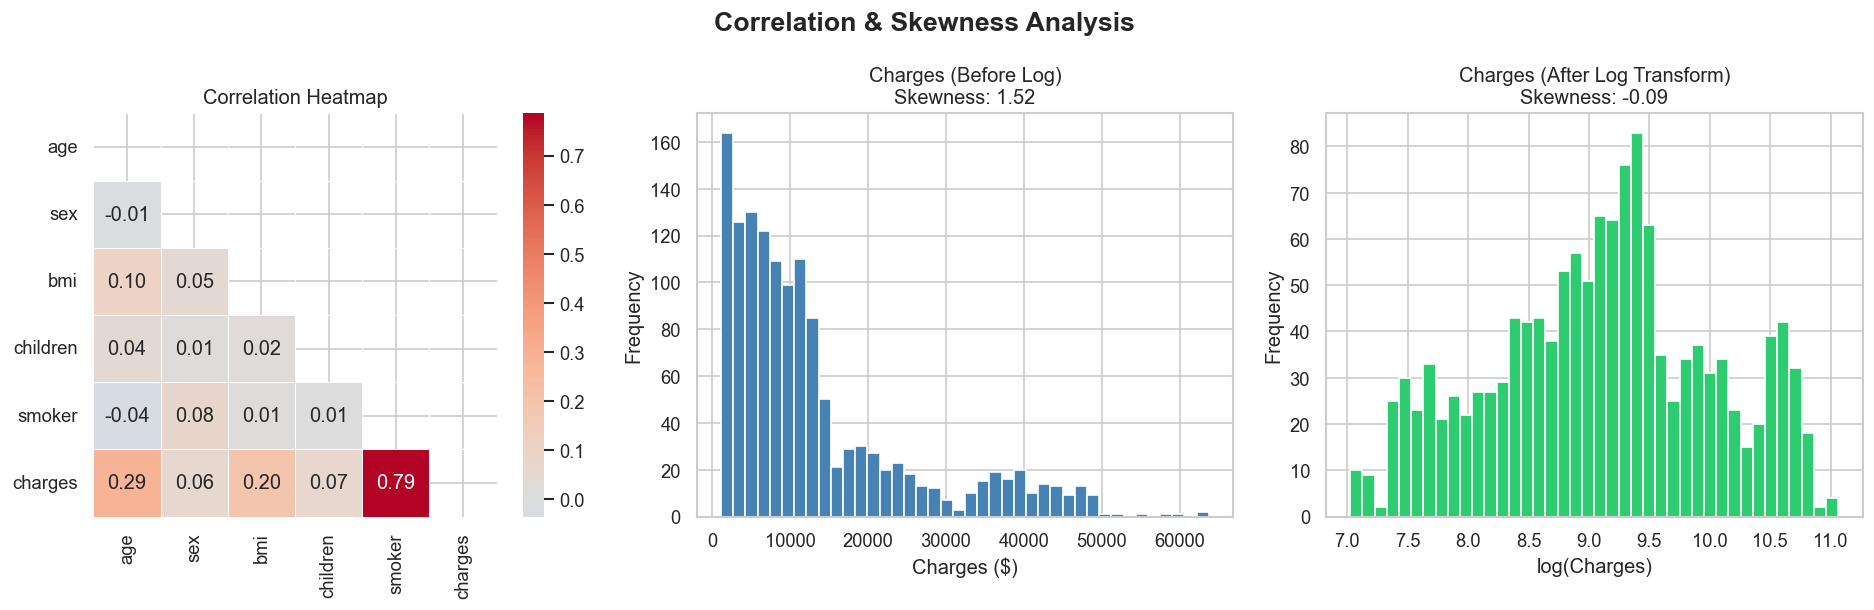

In [14]:
from sklearn.calibration import LabelEncoder


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Correlation & Skewness Analysis", fontsize=16, fontweight='bold')

# Temp encode for correlation
df_temp = df.copy()
df_temp['sex']    = LabelEncoder().fit_transform(df_temp['sex'].astype(str))
df_temp['smoker'] = LabelEncoder().fit_transform(df_temp['smoker'].astype(str))
df_temp['region'] = LabelEncoder().fit_transform(df_temp['region'].astype(str))

# 3A — Correlation heatmap
corr = df_temp[['age', 'sex', 'bmi', 'children', 'smoker', 'charges']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title("Correlation Heatmap")

# 3B — Charges before log transform
axes[1].hist(df['charges'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title(f"Charges (Before Log)\nSkewness: {df['charges'].skew():.2f}")
axes[1].set_xlabel("Charges ($)")
axes[1].set_ylabel("Frequency")

# 3C — Charges after log transform
log_charges = np.log1p(df['charges'])
axes[2].hist(log_charges, bins=40, color='#2ecc71', edgecolor='white')
axes[2].set_title(f"Charges (After Log Transform)\nSkewness: {log_charges.skew():.2f}")
axes[2].set_xlabel("log(Charges)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


Data Preprocessing

In [21]:
# Remove duplicates (spotted in overview)
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import train_test_split


df.drop_duplicates(inplace=True)
print(f"After removing duplicates: {df.shape}")

# Handle missing values (median — confirmed right-skewed from EDA)
df['age'].fillna(df['age'].median(), inplace=True)
df['bmi'].fillna(df['bmi'].median(), inplace=True)
print(f"Missing values remaining: {df.isnull().sum().sum()}")

# Log transform charges (confirmed skewed in Plot 3)
df['charges_log'] = np.log1p(df['charges'])

# Outlier capping via IQR
for col in ['bmi', 'charges']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# Encode categoricals
le = LabelEncoder()
df['sex']    = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df = pd.get_dummies(df, drop_first=True)

# Feature Engineering (motivated by BMI vs Charges scatter)
df['bmi_category'] = pd.cut(df['bmi'],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=['underweight', 'normal', 'overweight', 'obese'])
df['bmi_category'] = LabelEncoder().fit_transform(df['bmi_category'].astype(str))
df['smoker_obese']  = ((df['smoker'] == 1) & (df['bmi'] >= 30)).astype(int)
df['age_group']     = pd.cut(df['age'], bins=[18, 35, 50, 100],
                              labels=['young', 'middle', 'senior'])
df['age_group'] = LabelEncoder().fit_transform(df['age_group'].astype(str))

# Key finding (print clearly)
print("\n── KEY FINDING ──")
avg_smoker    = df[df['smoker'] == 1]['charges'].mean()
avg_nonsmoker = df[df['smoker'] == 0]['charges'].mean()
print(f"Smoker avg charges    : ${avg_smoker:,.2f}")
print(f"Non-smoker avg charges: ${avg_nonsmoker:,.2f}")
print(f"Smokers pay {avg_smoker/avg_nonsmoker:.1f}x more!")

# Split & Scale
X = df.drop(columns=['charges', 'charges_log'])
y = df['charges_log']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=pd.qcut(y, q=4, labels=False))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n── Final Output ──")
print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print(f"Features: {list(X_train.columns)}")
print("\n✅ EDA + Preprocessing complete. Data is model-ready!")

After removing duplicates: (1338, 13)
Missing values remaining: 214

── KEY FINDING ──
Smoker avg charges    : $28,206.27
Non-smoker avg charges: $8,429.40
Smokers pay 3.3x more!

── Final Output ──
Train : (1070, 11)
Test  : (268, 11)
Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_southeast', 'region_southwest', 'bmi_category', 'smoker_obese', 'age_group', 'region_northwest_True']

✅ EDA + Preprocessing complete. Data is model-ready!


In [18]:
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'charges_log',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category', 'smoker_obese', 'age_group'],
      dtype='str')
